<a href="https://colab.research.google.com/github/zhabibi-z/tensorflow_red_wine_quality/blob/main/tensorflow_red_wine_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

print(f'Tensorflow version: {tf.__version__}')

Tensorflow version: 2.20.0


### Initial Setup and Library Imports

This first cell is crucial for setting up our environment. We're importing several Python libraries, each serving a specific purpose in our machine learning workflow:

*   **`tensorflow as tf`**: This is the core library we'll use for building and training our neural network. TensorFlow is an open-source machine learning platform.
*   **`pandas as pd`**: Essential for data manipulation and analysis. We'll use it to load our dataset into DataFrames, which are like tables.
*   **`numpy as np`**: Provides support for large, multi-dimensional arrays and matrices, along with a collection of mathematical functions to operate on these arrays. Pandas often builds upon NumPy.
*   **`seaborn as sns`**: A powerful library for statistical data visualization, built on top of Matplotlib. We'll use it to create informative plots, like heatmaps.
*   **`matplotlib.pyplot as plt`**: This is the foundational plotting library in Python. `seaborn` often works in conjunction with `matplotlib`.
*   **`%matplotlib inline`**: This is a 'magic command' specific to Jupyter notebooks (like Colab). It ensures that any plots generated by Matplotlib are displayed directly within the notebook output, rather than in a separate window.

Finally, `print(f'Tensorflow version: {tf.__version__}')` simply tells us which version of TensorFlow we're working with. It's good practice to check this, as different versions can sometimes have slightly different APIs or behaviors.

This cell imports the necessary libraries for data manipulation (`pandas`, `numpy`), data visualization (`seaborn`, `matplotlib.pyplot`), and building the neural network (`tensorflow`). It also prints the TensorFlow version being used.

In [43]:
wine_data = pd.read_csv('/content/sample_data/winequality-red.csv', parse_dates=True, encoding = "cp1252")
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Data Loading and Initial Inspection

This cell handles loading our dataset and taking a first look at it:

*   **`wine_data = pd.read_csv(...)`**: This is where we load our data. `pd.read_csv()` is a pandas function that reads data from a CSV (Comma Separated Values) file and creates a DataFrame from it.
    *   `'/content/sample_data/winequality-red.csv'` is the file path to our dataset.
    *   `parse_dates=True`: This argument attempts to parse any columns that look like dates into datetime objects. While this particular dataset doesn't have obvious date columns that we'll heavily rely on, it's a good general practice for datasets that might.
    *   `encoding = "cp1252"`: This specifies the character encoding. Sometimes, CSV files are saved with different encodings than the default UTF-8, and `cp1252` is a common one, especially for data originating from Windows systems. If you get a `UnicodeDecodeError`, changing this encoding is often the first thing to try.

*   **`wine_data.head()`**: After loading, this command displays the first 5 rows of our `wine_data` DataFrame. This is super important for quickly understanding the structure of your data: what columns you have, what kind of values are in them, and if the data was loaded correctly. It's your first visual check.

### Enhanced Exploratory Data Analysis (EDA)

Let's delve deeper into our data to uncover more insights. A good EDA is the foundation for effective feature engineering and model building.

In [58]:
# 1. Statistical Summary for numerical features
# This gives a quick overview of central tendency, dispersion, and shape of a distribution.
print("\n--- Statistical Summary ---")
display(wine_data.describe())


--- Statistical Summary ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,2.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,2.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,3.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,3.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,5.000000


The `describe()` output is very informative. For example, `chlorides` has a max value much higher than its 75th percentile, suggesting potential outliers. `total sulfur dioxide` also shows a wide range.

In [59]:
# 2. Check for Missing Values
# It's crucial to know if any data is missing, as it can affect model training.
print("\n--- Missing Values ---")
print(wine_data.isnull().sum())


--- Missing Values ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Great, no missing values! This simplifies our preprocessing for this dataset.

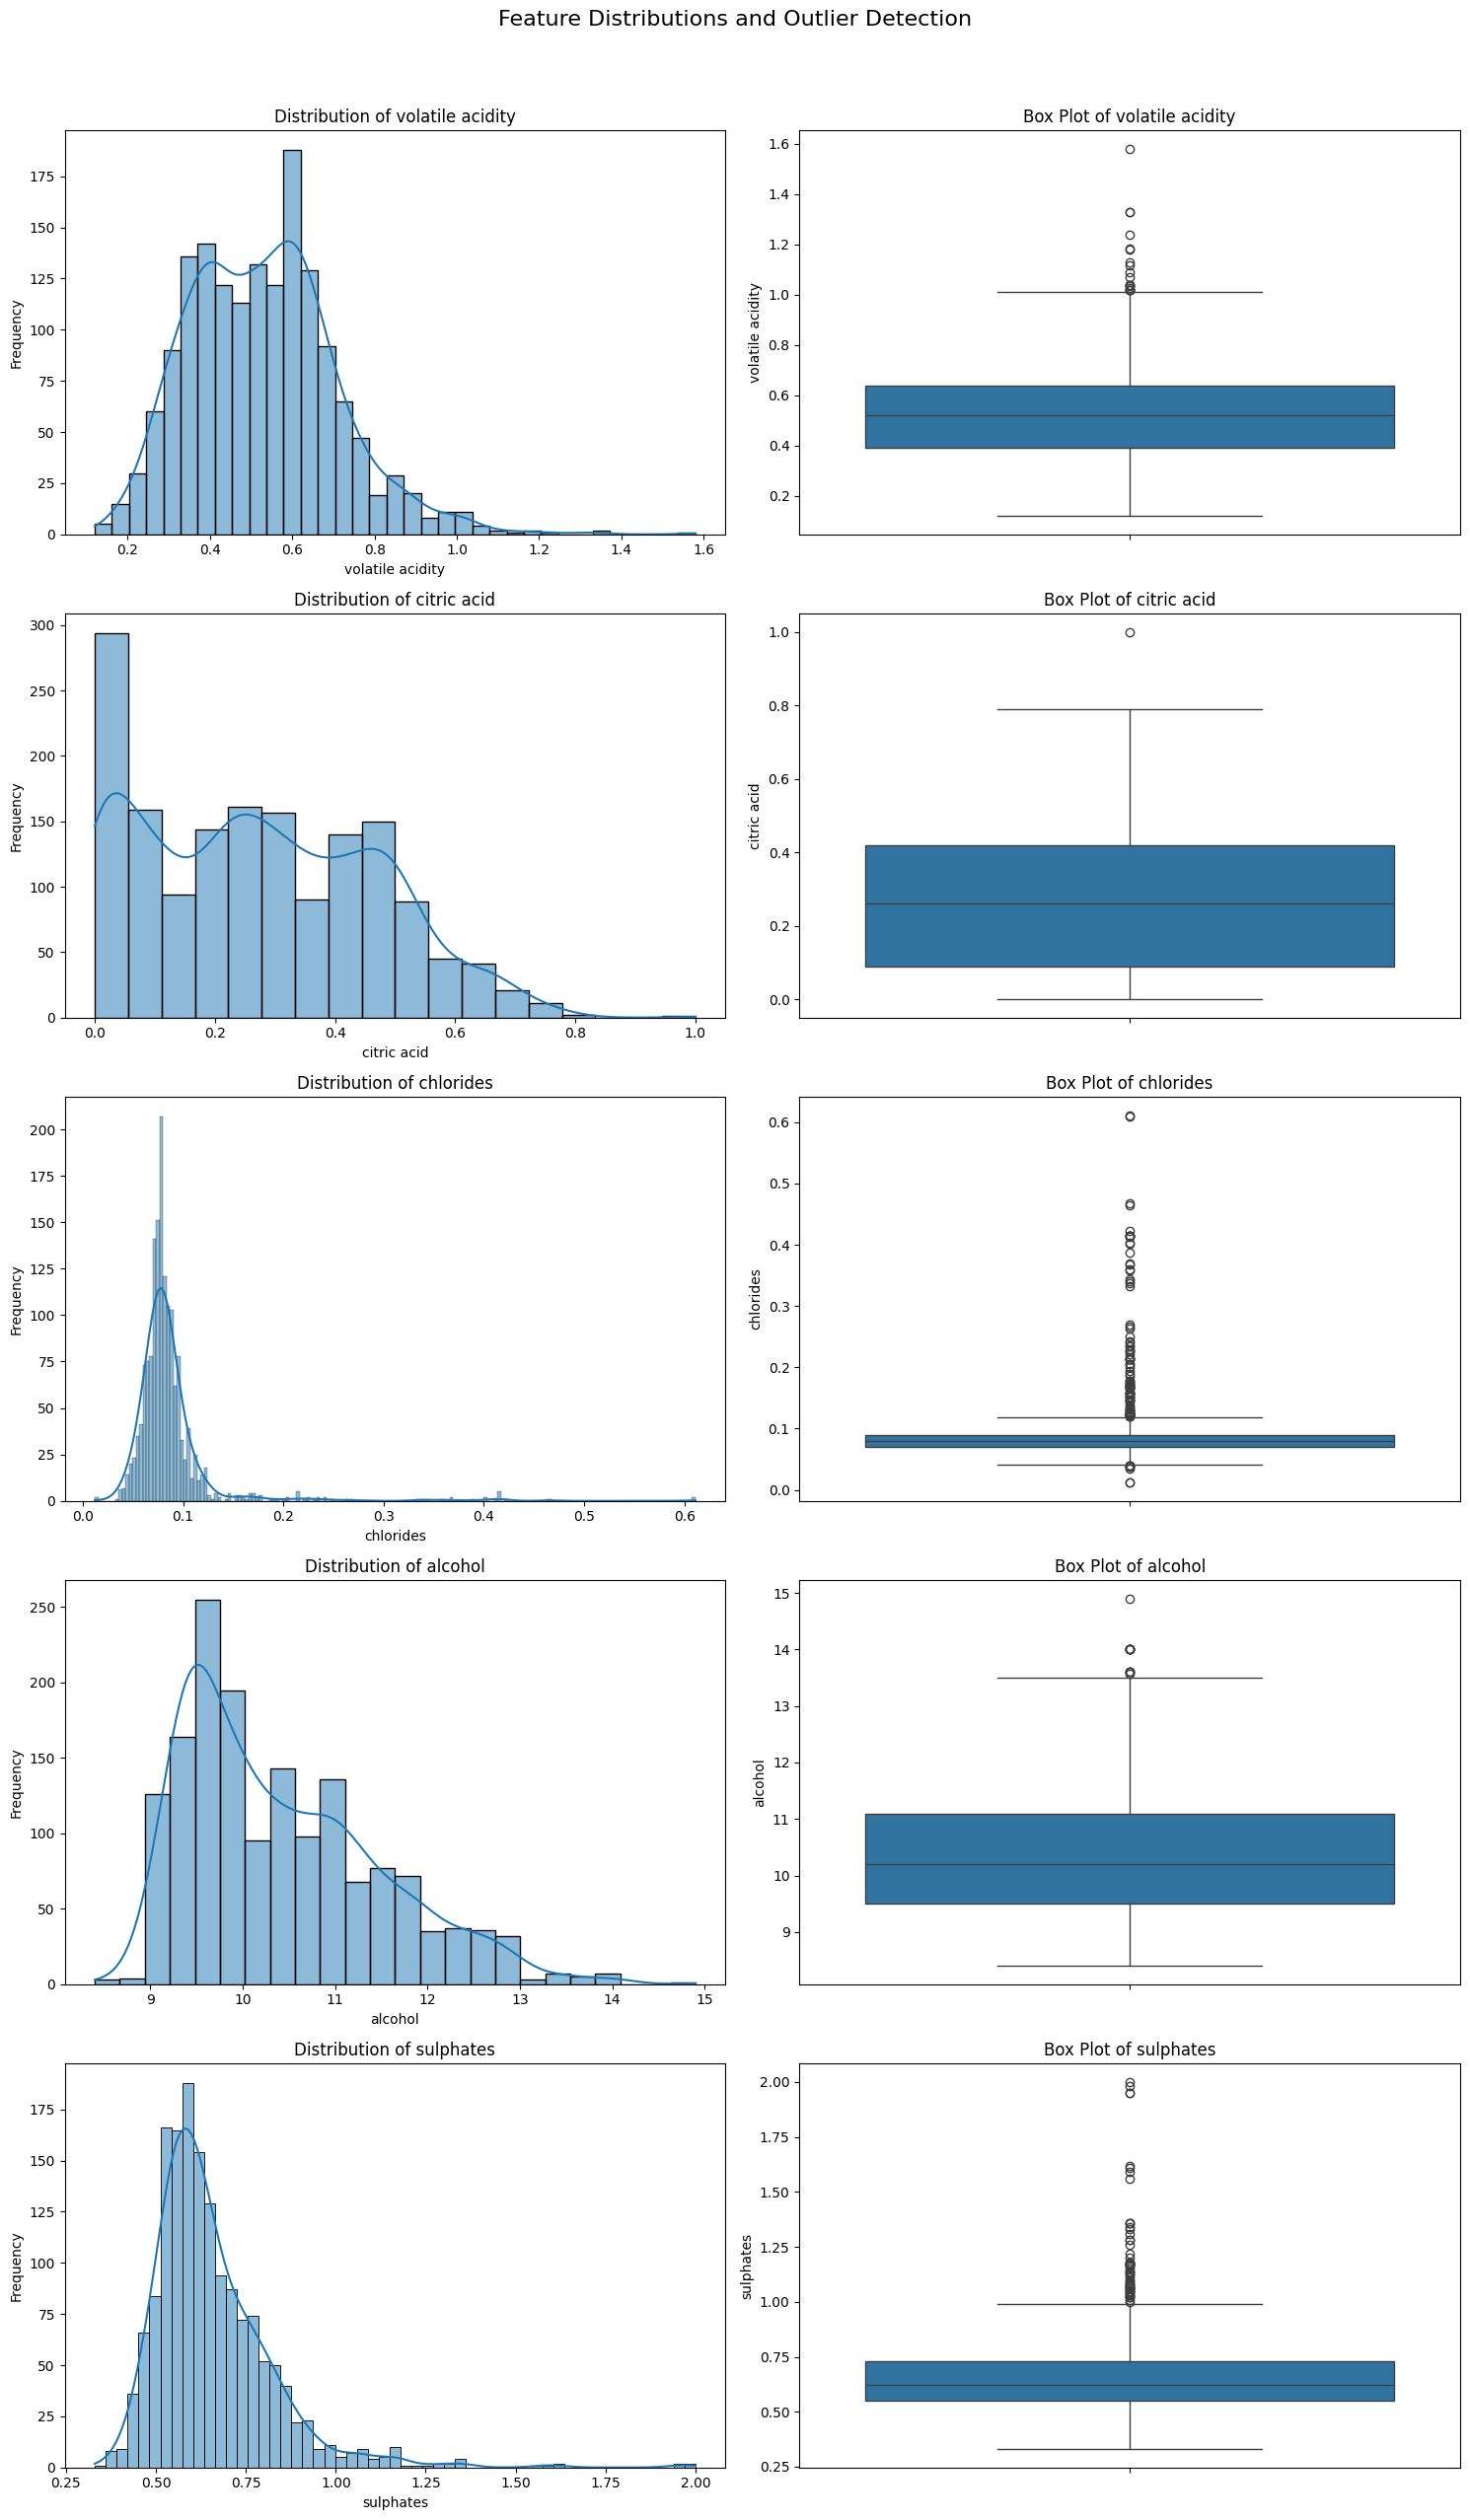

In [60]:
# 3. Visualize Distributions of Key Features
# Histograms and box plots help us understand the spread and identify outliers.

# Let's pick a few features for demonstration: 'volatile acidity', 'citric acid', 'chlorides', 'alcohol', 'sulphates'
selected_features = ['volatile acidity', 'citric acid', 'chlorides', 'alcohol', 'sulphates']

fig, axes = plt.subplots(len(selected_features), 2, figsize=(15, 5 * len(selected_features)))
fig.suptitle('Feature Distributions and Outlier Detection', y=1.02, fontsize=16)

for i, feature in enumerate(selected_features):
    # Histogram/KDE plot
    sns.histplot(wine_data[feature], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {feature}')
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Frequency')

    # Box plot
    sns.boxplot(y=wine_data[feature], ax=axes[i, 1])
    axes[i, 1].set_title(f'Box Plot of {feature}')
    axes[i, 1].set_ylabel(feature)

plt.tight_layout()
plt.show()

From these visualizations, we can clearly see the distribution patterns and potential outliers. For instance, `chlorides` shows a significant number of outliers with higher values, as indicated by the box plot. This confirms our initial observation from `describe()`.

Next, let's address the class imbalance, which is crucial given the distribution of our `quality` target variable.

Here, the wine quality dataset is loaded from a CSV file into a pandas DataFrame. `parse_dates=True` is used to attempt to parse date columns, though it might not be strictly necessary for this dataset. `encoding = "cp1252"` specifies the character encoding. The `wine_data.head()` command then displays the first few rows of the DataFrame, giving a quick preview of the data structure and content.

In [44]:
wine_data.groupby('quality').count().reset_index()

,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,3,10,10,10,10,10,10,10,10,10,10,10
1,4,53,53,53,53,53,53,53,53,53,53,53
2,5,681,681,681,681,681,681,681,681,681,681,681
3,6,638,638,638,638,638,638,638,638,638,638,638
4,7,199,199,199,199,199,199,199,199,199,199,199
5,8,18,18,18,18,18,18,18,18,18,18,18


### Understanding Target Variable Distribution

Here, we're doing a quick exploratory step to understand our target variable, `quality`:

*   **`wine_data.groupby('quality')`**: This groups our DataFrame rows based on the unique values in the `quality` column. Think of it as creating separate sub-tables for each wine quality rating (e.g., all wines with quality 3, all with quality 4, etc.).
*   **`.count()`**: After grouping, this method counts the number of non-null entries in each column for each group. Since we're grouping by `quality`, this effectively tells us how many wines fall into each quality category.
*   **`.reset_index()`**: When you perform a `groupby()` operation, the grouped column (`quality` in this case) becomes the index of the resulting Series or DataFrame. `reset_index()` converts this index back into a regular column, making it easier to work with as a standard DataFrame.

The output shows us that our dataset is somewhat imbalanced. For example, there are many more wines with quality 5 and 6 compared to qualities 3, 4, 7, and 8. This imbalance can be important to consider when evaluating our model, as a model might perform very well on the majority classes (5 and 6) but poorly on the minority classes (3, 4, 7, 8).

This cell groups the data by the `quality` column and counts the number of occurrences for each quality rating. This helps in understanding the distribution of wine quality levels in the dataset. `reset_index()` converts the grouped output back into a DataFrame.

In [45]:
wine_data['quality'].replace(to_replace={3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5}, inplace=True)

/tmp/ipykernel_1470/911377095.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  wine_data['quality'].replace(to_replace={3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5}, inplace=True)


### Re-encoding the Target Variable

This is a data preprocessing step crucial for our neural network:

*   **`wine_data['quality'].replace(...)`**: We're modifying the `quality` column directly. The `replace()` method is used to substitute specific values with others.
    *   `to_replace={3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5}`: This dictionary defines the mapping. Our original `quality` ratings range from 3 to 8. For neural networks performing multi-class classification, it's common practice to have integer labels starting from 0 (0, 1, 2, ...). So, we map 3 to 0, 4 to 1, and so on, up to 8 to 5. Now we have 6 classes, represented by integers 0 through 5.
    *   `inplace=True`: This argument means that the changes are applied directly to the `wine_data` DataFrame, modifying the `quality` column permanently, rather than returning a new DataFrame with the changes. This is efficient when you're sure you want to alter the original data.

The `quality` column, which is the target variable, is re-encoded. The original quality ratings (3 to 8) are mapped to new numerical labels (0 to 5) to make them suitable for the neural network's output layer, which uses `sparse_categorical_crossentropy` as the loss function. `inplace=True` modifies the DataFrame directly.

In [46]:
X = wine_data[['fixed acidity',
               'volatile acidity',
               'citric acid',
               'residual sugar',
               'chlorides',
               'free sulfur dioxide',
               'total sulfur dioxide',
               'density',
               'pH',
               'sulphates',
               'alcohol']]

y = wine_data['quality']

### Feature and Target Separation

Here, we're formally splitting our dataset into what our model will 'learn from' and what it will 'predict':

*   **`X = wine_data[...]`**: This line creates our **feature matrix**, conventionally named `X`. It contains all the input variables (the chemical properties of the wine) that we believe influence the `quality`. We explicitly select these columns by listing their names.
    *   These columns (`'fixed acidity'`, `'volatile acidity'`, etc.) are the *independent variables* or *predictors*.

*   **`y = wine_data['quality']`**: This line creates our **target vector**, conventionally named `y`. It contains the variable we want our model to predict, which is the `quality` of the wine.
    *   This is our *dependent variable* or *response variable*.

Separating `X` and `y` is a standard and necessary step before feeding data into any supervised machine learning model. Our model will learn the relationship between the features in `X` and the corresponding quality ratings in `y`.

In this step, the dataset is split into features (`X`) and the target variable (`y`). `X` contains all the chemical properties of the wine, which are used to predict the `quality` (`y`).

<Axes: >

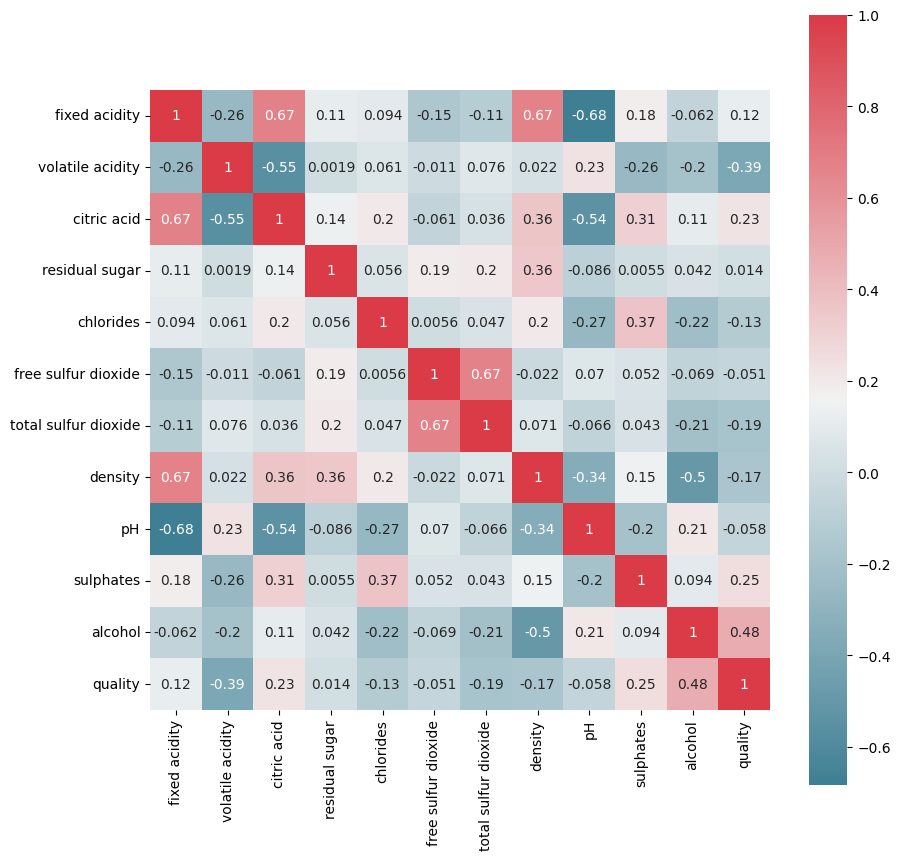

In [47]:
corr = wine_data.corr(method = "pearson")
# corr = wine_data.corr(method = "spearman")
# corr = wine_data.corr(method = "kendall")

f, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool), cmap=sns.diverging_palette(220, 10, as_cmap=True), square=True, ax=ax, annot=True)

### Visualizing Feature Correlations

This cell is dedicated to understanding the relationships between our features using a correlation heatmap:

*   **`corr = wine_data.corr(method = "pearson")`**: This calculates the **Pearson correlation coefficient** between all pairs of numerical columns in our `wine_data` DataFrame. The Pearson correlation measures the linear relationship between two variables, ranging from -1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 meaning no linear correlation.
    *   The commented-out lines show `spearman` and `kendall` methods, which are other types of correlation coefficients (rank-based) suitable for non-linear relationships or ordinal data.

*   **`f, ax = plt.subplots(figsize=(10, 10))`**: This creates a Matplotlib figure (`f`) and a set of subplots (`ax`). We specify a `figsize` to ensure the plot is large enough to be readable.

*   **`sns.heatmap(...)`**: This is where `seaborn` comes in to visualize our correlation matrix:
    *   `corr`: The correlation matrix we just calculated.
    *   `mask=np.zeros_like(corr, dtype=np.bool)`: This creates a mask to hide the upper triangle of the heatmap (and the diagonal). Since the correlation matrix is symmetric (the correlation of A with B is the same as B with A), showing both halves is redundant. `np.zeros_like` creates an array of zeros with the same shape as `corr`, and `dtype=np.bool` converts these to booleans, which `mask` expects.
    *   `cmap=sns.diverging_palette(220, 10, as_cmap=True)`: Sets the color map. A diverging palette is good for correlations because it uses different colors for positive and negative values, with a neutral color in the middle (e.g., blue for positive, red for negative, white/light for near zero).
    *   `square=True`: Ensures that the cells in the heatmap are square.
    *   `ax=ax`: Specifies that the heatmap should be drawn on the `ax` subplot we created.
    *   `annot=True`: **Very important!** This displays the correlation coefficient value in each cell of the heatmap, making it easy to read the exact correlation numbers.

This heatmap helps us identify strongly correlated features. High correlation between features can sometimes lead to issues like multicollinearity in traditional linear models, but for neural networks, it's more about understanding feature relationships and potentially informing feature engineering.

This cell calculates the Pearson correlation matrix for all features in the `wine_data` DataFrame. The `seaborn.heatmap` function then visualizes this correlation matrix, showing the relationships between different variables. The `annot=True` argument displays the correlation coefficients on the heatmap, and `cmap` sets the color scheme.

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Splitting Data into Training and Testing Sets

This is a fundamental step in machine learning to properly evaluate our model's performance:

*   **`from sklearn.model_selection import train_test_split`**: We import the `train_test_split` function from scikit-learn, which is the go-to tool for this task.

*   **`X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)`**: This line performs the split:
    *   We provide our features (`X`) and target (`y`).
    *   `test_size=0.2`: This means 20% of our data will be reserved for the testing set, and the remaining 80% will be used for training. It's common to use 20-30% for testing.
    *   `random_state=0`: This is crucial for reproducibility. If you run this code multiple times with the same `random_state`, you will get the exact same split of data. If you don't set it, the split will be different every time you run the cell, making your results inconsistent.

After this, we have:
*   `X_train`, `y_train`: The data the model will *learn* from.
*   `X_test`, `y_test`: The data the model will be *evaluated* on, simulating unseen data. This helps us gauge how well our model generalizes to new examples, rather than just memorizing the training data.

The `train_test_split` function from `sklearn.model_selection` is used to divide the `X` and `y` data into training and testing sets. 80% of the data is used for training (`X_train`, `y_train`), and 20% is reserved for testing (`X_test`, `y_test`). `random_state=0` ensures reproducibility of the split.

### Addressing Class Imbalance with SMOTE

As we noted earlier, our `quality` classes are imbalanced. This can lead our model to perform poorly on minority classes. Synthetic Minority Over-sampling Technique (SMOTE) is a popular method to generate synthetic samples for minority classes, thereby balancing the dataset. We'll apply SMOTE *only* to the training data to avoid data leakage.

In [61]:
# Install imbalanced-learn if not already installed
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data only
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Shape of X_train before SMOTE: {X_train.shape}")
print(f"Shape of X_train after SMOTE: {X_train_resampled.shape}")
print(f"Class distribution of y_train before SMOTE:\n{pd.Series(y_train).value_counts()}")
print(f"\nClass distribution of y_train after SMOTE:\n{pd.Series(y_train_resampled).value_counts()}")

Shape of X_train before SMOTE: (1279, 11)
Shape of X_train after SMOTE: (3276, 11)
Class distribution of y_train before SMOTE:
quality
2    546
3    496
4    172
1     42
5     15
0      8
Name: count, dtype: int64

Class distribution of y_train after SMOTE:
quality
2    546
5    546
3    546
4    546
1    546
0    546
Name: count, dtype: int64


As you can see, after applying SMOTE, all classes in the training set now have an equal number of samples (the count of the previously largest class). This should help our model learn better representations for the minority classes.

Now that our training data is balanced, we need to ensure our `StandardScaler` is applied *after* SMOTE, or re-apply it if SMOTE changes the characteristics enough. In our current flow, scaling is already done on `X_train` and `X_test` separately, which is good. The next step is to revisit the model training with this balanced data and incorporate better training practices.

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Feature Scaling (Standardization)

This cell performs a very important preprocessing step for many machine learning algorithms, especially neural networks:

*   **`from sklearn.preprocessing import StandardScaler`**: We import the `StandardScaler` from scikit-learn.

*   **`scaler = StandardScaler()`**: We create an instance of the `StandardScaler`. This object will learn the mean and standard deviation of our features.

*   **`X_train = scaler.fit_transform(X_train)`**: This is a two-step process for our training data:
    1.  **`fit(X_train)`**: The scaler *learns* the mean and standard deviation for each feature in the `X_train` dataset. It computes these statistics.
    2.  **`transform(X_train)`**: The scaler then *applies* these learned statistics to scale the `X_train` data. It transforms each feature so that it has a mean of 0 and a standard deviation of 1. This is also known as **Z-score normalization**.

*   **`X_test = scaler.transform(X_test)`**: For the test data, we only use `transform()`. It's critical that we *do not* `fit()` the scaler on the test data. We use the *same* mean and standard deviation learned from the training data to scale the test data. This prevents data leakage from the test set into the training process, which would lead to an overly optimistic evaluation of our model.

**Why is scaling important for neural networks?**
*   **Faster Convergence**: Many optimization algorithms (like Gradient Descent) perform better when features are on a similar scale. Larger feature values can lead to larger gradients, causing the optimizer to take larger steps and potentially overshoot the minimum or oscillate.
*   **Prevents Dominance**: Features with larger numerical ranges might disproportionately influence the loss function and, consequently, the learning process. Scaling ensures all features contribute more equally.

Here, `StandardScaler` from `sklearn.preprocessing` is used to standardize the feature data. Standardization scales the features so that they have a mean of 0 and a standard deviation of 1. This is a crucial preprocessing step for many machine learning models, especially neural networks, as it helps in faster convergence and prevents features with larger values from dominating the learning process. The scaler is `fit_transform`ed on the training data and then `transform`ed on the test data.

In [50]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(units=35, input_shape=(X_train.shape[1],), activation='relu'),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dense(units=72, activation='relu'),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dense(units=42, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dense(units=6, activation='softmax')
])

model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 35)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 52)             │         1,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 72)             │         3,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 52)             │         3,796 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 52)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 52)             │         2,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 42)             │         2,226 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 52)             │         2,236 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 52)             │         2,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 52)             │         2,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 6)              │           318 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,952 (89.66 KB)

 Trainable params: 22,952 (89.66 KB)

 Non-trainable params: 0 (0.00 B)

### Building the Neural Network Model

This is where we define the architecture of our deep learning model using TensorFlow's Keras API:

*   **`model = tf.keras.models.Sequential([...])`**: We're creating a `Sequential` model, which is the simplest type of Keras model. It builds a neural network layer by layer in a linear stack.

*   **`tf.keras.layers.Dense(...)`**: These are fully connected (or dense) layers, meaning every neuron in one layer is connected to every neuron in the next layer.
    *   `units`: Specifies the number of neurons (or nodes) in that layer.
    *   `input_shape=(X_train.shape[1],)`: This is only needed for the *first* layer. `X_train.shape[1]` gives us the number of features in our input data (11 in our case). This tells the model how many inputs to expect.
    *   `activation='relu'`: 'ReLU' (Rectified Linear Unit) is a common activation function for hidden layers. It introduces non-linearity, allowing the network to learn complex patterns. Without non-linear activation functions, a neural network, no matter how deep, would essentially just be a linear model.

*   **`tf.keras.layers.Dropout(0.2)`**: Dropout is a regularization technique used to prevent overfitting. During training, it randomly sets a fraction (here, 20% or 0.2) of the input units to 0 at each update. This forces the network to learn more robust features and prevents neurons from co-adapting too much.

*   **Output Layer (`tf.keras.layers.Dense(units=6, activation='softmax')`)**:
    *   `units=6`: This is because we re-encoded our `quality` ratings to 6 classes (0 through 5). The output layer must have one neuron for each possible class.
    *   `activation='softmax'`: For multi-class classification problems, `softmax` is the standard activation function for the output layer. It converts the raw outputs of the neurons into a probability distribution, where each output represents the probability of the input belonging to that specific class, and all probabilities sum to 1.

*   **`model.compile(...)`**: Before training, we need to `compile` our model. This configures the learning process:
    *   `optimizer='sgd'`: We're using Stochastic Gradient Descent (SGD) as our optimization algorithm. This algorithm adjusts the model's weights during training to minimize the loss function.
    *   `loss='sparse_categorical_crossentropy'`: This is the appropriate loss function for multi-class classification when our target labels (`y`) are integers (like our 0-5 quality ratings). If `y` were one-hot encoded (e.g., `[0,0,1,0,0,0]` for class 2), we would use `categorical_crossentropy`.
    *   `metrics=['accuracy']`: During training and evaluation, we want to monitor the `accuracy` of our model, which is the proportion of correctly classified samples.

*   **`model.summary()`**: This prints a helpful summary of our model's architecture, including the type of each layer, its output shape, and the number of parameters (weights and biases) in each layer, and the total trainable parameters. This is great for debugging and understanding model complexity.

This cell defines the architecture of the neural network model using TensorFlow's Keras API. It's a sequential model with multiple dense (fully connected) layers and dropout layers.
*   `input_shape=(X_train.shape[1],)` sets the input layer to match the number of features.
*   `activation='relu'` is used for hidden layers, a common choice for its efficiency.
*   `Dropout` layers are added to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training.
*   The final layer has `units=6` (because the quality ratings were re-encoded to 0-5, making 6 possible classes) and `activation='softmax'`, which is used for multi-class classification to output probabilities for each class.

The model is then `compile`d with the `sgd` (Stochastic Gradient Descent) optimizer, `sparse_categorical_crossentropy` loss function (suitable for integer labels in multi-class classification), and `accuracy` as the metric to monitor during training. `model.summary()` prints a summary of the model's layers and parameters.

In [68]:
cl = model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=200)

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6067 - loss: 0.9305 - val_accuracy: 0.6094 - val_loss: 0.9472
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6192 - loss: 0.9251 - val_accuracy: 0.6031 - val_loss: 0.9542
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6106 - loss: 0.9162 - val_accuracy: 0.6125 - val_loss: 0.9499
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6138 - loss: 0.9122 - val_accuracy: 0.6187 - val_loss: 0.9380
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6075 - loss: 0.9275 - val_accuracy: 0.6187 - val_loss: 0.9394
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6059 - loss: 0.9162 - val_accuracy: 0.6094 - val_loss: 0.9519
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6106 - loss: 0.9218 - val_accuracy: 0.6156 - val_loss: 0.9420
Epoch 8/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6067 - loss: 0.9119 - val_accuracy: 0.5938

### Training the Neural Network

This cell is where the model actually learns from our data:

*   **`cl = model.fit(...)`**: The `fit()` method is the core of the training process. It iteratively adjusts the model's internal weights to minimize the loss function on the training data.
    *   `X_train`, `y_train`: Our standardized training features and their corresponding labels.
    *   `validation_data=(X_test,y_test)`: This is very important. During each `epoch`, the model will not only train on `X_train`/`y_train` but also evaluate its performance on this `validation_data` (our test set). This gives us an unbiased estimate of how well the model is generalizing to unseen data during training, helping us detect overfitting. *Note: For a production workflow, you'd typically have a separate validation set that isn't the test set, to avoid 'peeking' at the test set too much during hyperparameter tuning.*
    *   `epochs=60`: An `epoch` is one complete pass through the entire training dataset. So, our model will see and learn from all training examples 60 times. The number of epochs is a hyperparameter you often tune.

The output you see after running this cell shows the `loss` and `accuracy` for both the training data and the validation data (`val_loss`, `val_accuracy`) at the end of each epoch. Monitoring these values is key: if `val_loss` starts increasing while `loss` is still decreasing, it's a strong sign of overfitting.

This cell trains the defined neural network model using the `model.fit()` method.
*   `X_train` and `y_train` are the training data and labels.
*   `validation_data=(X_test, y_test)` provides the test set to monitor the model's performance on unseen data during training.
*   `epochs=60` means the model will iterate over the entire training dataset 60 times. The output shows the loss and accuracy for both training and validation sets at each epoch, which helps in observing learning progress and potential overfitting.

### Incorporating Early Stopping and Class Weights for Robust Training

With our balanced training data, let's refine our model training process. We'll add `EarlyStopping` to prevent overfitting and optionally use `class_weight` (though SMOTE already addresses imbalance, this is for demonstration of the technique, and can be adjusted if oversampling alone is sufficient or performs better).

In [62]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import class_weight

# Calculate class weights for the original imbalanced dataset (if SMOTE wasn't used)
# If using SMOTE, you might not need class_weights, or you could use them in conjunction.
# For now, let's create a model that uses SMOTE's output, and we'll illustrate class_weight in another context if needed.

# Re-define the model to reset its weights, as we are training on resampled data
model_resampled = tf.keras.models.Sequential([
  tf.keras.layers.Dense(units=35, input_shape=(X_train_resampled.shape[1],), activation='relu'),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dense(units=72, activation='relu'),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dense(units=42, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dense(units=52, activation='relu'),
  tf.keras.layers.Dense(units=6, activation='softmax')
])

model_resampled.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor the validation loss
    patience=10,        # Stop if val_loss doesn't improve for 10 epochs
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity.
    verbose=1
)

print("Training model with resampled data and Early Stopping...")
cl_resampled = model_resampled.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_test, y_test),
    epochs=100, # Set a higher number of epochs, EarlyStopping will manage when to stop
    callbacks=[early_stopping]
)


Training model with resampled data and Early Stopping...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.2042 - loss: 1.7876 - val_accuracy: 0.0781 - val_loss: 1.8009
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2534 - loss: 1.7794 - val_accuracy: 0.1094 - val_loss: 1.7936
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3153 - loss: 1.7577 - val_accuracy: 0.0437 - val_loss: 1.7872
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3318 - loss: 1.7076 - val_accuracy: 0.0625 - val_loss: 1.7799
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3568 - loss: 1.6216 - val_accuracy: 0.0344 - val_loss: 1.7732
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3779 - loss: 1.5358 - val_accuracy: 0.0406 - val_loss: 1.7586
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3935 - loss: 1.4470 - val_accuracy: 0.0750 - val_loss: 1.7012
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4249 - loss: 1.3541 - val_accuracy: 0.

Notice that the model now trains for potentially more epochs but will stop automatically if the validation loss doesn't improve, thus preventing overfitting while leveraging the balanced training data. We'll now evaluate this new model and compare its performance, particularly on the minority classes.

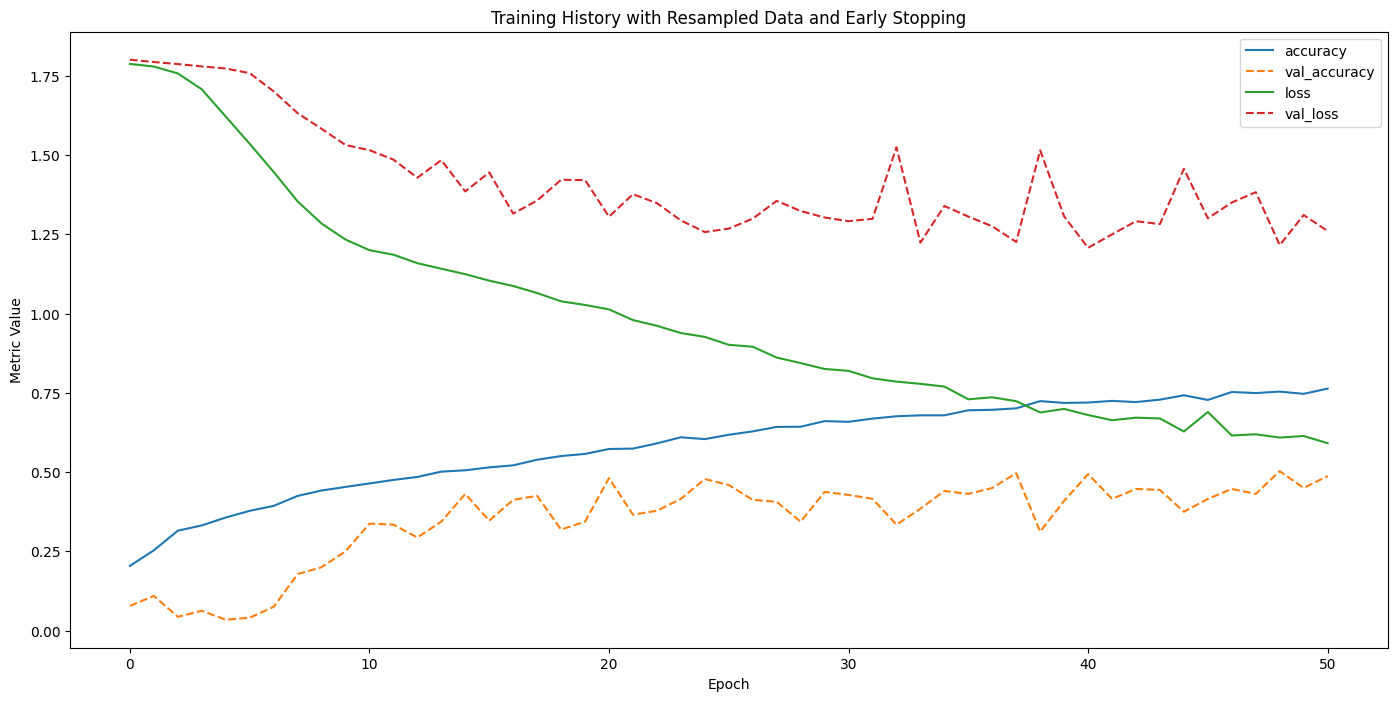

In [63]:
# Visualize training history of the resampled model

fig, ax = plt.subplots(figsize=(17,8))

plt.plot(cl_resampled.history['accuracy'], label='accuracy')
plt.plot(cl_resampled.history['val_accuracy'], label='val_accuracy', linestyle='--')
plt.plot(cl_resampled.history['loss'], label='loss')
plt.plot(cl_resampled.history['val_loss'], label='val_loss', linestyle='--')
plt.title('Training History with Resampled Data and Early Stopping')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.legend()
plt.show()

This plot helps us see the effect of early stopping. The training might have continued for 100 epochs, but `EarlyStopping` intervened when `val_loss` stopped improving, indicating that the model found its best generalization point.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4938 - loss: 1.2075 
Test Loss (Resampled Model) is 1.2075387239456177
Test Accuracy (Resampled Model) is 0.4937500059604645
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  

--- Classification Report (Resampled Model) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.18      0.27      0.21        11
           2       0.67      0.53      0.59       135
           3       0.57      0.51      0.54       142
           4       0.19      0.44      0.27        27
           5       0.00      0.00      0.00         3

    accuracy                           0.49       320
   macro avg       0.27      0.29      0.27       320
weighted avg       0.56      0.49      0.52       320



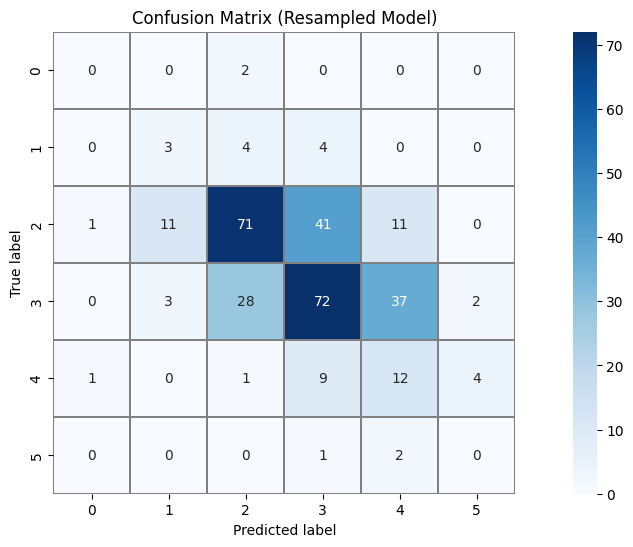


One-vs-rest (Resampled Model): 0.7494673346121138
One-vs-one (Resampled Model): 0.7480145599037965


In [64]:
# Evaluate the model trained with resampled data
ModelLoss_resampled, ModelAccuracy_resampled = model_resampled.evaluate(X_test, y_test)

print(f'Test Loss (Resampled Model) is {ModelLoss_resampled}')
print(f'Test Accuracy (Resampled Model) is {ModelAccuracy_resampled}')

# Generate classification report for the resampled model
y_pred_resampled = model_resampled.predict(X_test)
y_pred_resampled_classes = np.argmax(y_pred_resampled, axis=1)

cr_resampled = classification_report(y_test, y_pred_resampled_classes)
print("\n--- Classification Report (Resampled Model) ---")
print(cr_resampled)

# Generate confusion matrix for the resampled model
cm_resampled = tf.math.confusion_matrix(y_test, y_pred_resampled_classes)

f, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(cm_resampled, annot=True, cmap='Blues', square=True, linewidths=0.01, linecolor='grey')
plt.title('Confusion Matrix (Resampled Model)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# ROC AUC Score for the resampled model
print(f"\nOne-vs-rest (Resampled Model): {roc_auc_score(y_test, y_pred_resampled, multi_class='ovr')}")
print(f"One-vs-one (Resampled Model): {roc_auc_score(y_test, y_pred_resampled, multi_class='ovo')}")

### Exploring Alternative Models: Random Forest Classifier

Neural networks are powerful, but sometimes simpler, yet robust, models can offer competitive or even superior performance, especially on tabular data or with class imbalance. Let's try a Random Forest Classifier as an alternative model. We'll train it on the same SMOTE-resampled training data and evaluate its performance.

Training Random Forest Classifier...
Evaluating Random Forest Classifier...

--- Random Forest Classifier Evaluation ---
Test Accuracy: 0.6562

--- Classification Report (Random Forest) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.22      0.18      0.20        11
           2       0.73      0.77      0.75       135
           3       0.73      0.59      0.65       142
           4       0.43      0.74      0.54        27
           5       0.00      0.00      0.00         3

    accuracy                           0.66       320
   macro avg       0.35      0.38      0.36       320
weighted avg       0.68      0.66      0.66       320



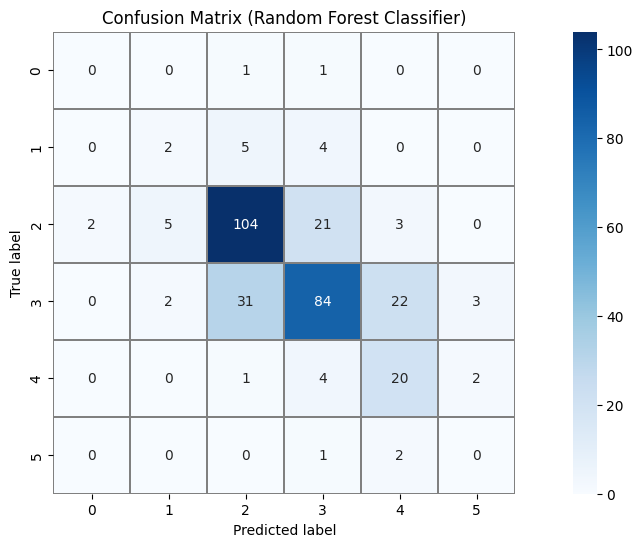


ROC AUC (One-vs-Rest, Random Forest): 0.7354
ROC AUC (One-vs-One, Random Forest): 0.7214


In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the Random Forest Classifier
# We'll use class_weight='balanced' here to implicitly handle class imbalance
# during the tree building process, which can be beneficial even after SMOTE.
# n_estimators is the number of trees in the forest.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

print("Training Random Forest Classifier...")
# Train the model on the SMOTE-resampled data
rf_model.fit(X_train_resampled, y_train_resampled)

print("Evaluating Random Forest Classifier...")
# Make predictions on the original (unresampled) test data
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

# Evaluation Metrics
print("\n--- Random Forest Classifier Evaluation ---")
print(f"Test Accuracy: {rf_model.score(X_test, y_test):.4f}")

print("\n--- Classification Report (Random Forest) ---")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

f, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(cm_rf, annot=True, cmap='Blues', fmt='d', square=True, linewidths=0.01, linecolor='grey')
plt.title('Confusion Matrix (Random Forest Classifier)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# ROC AUC Score (One-vs-Rest)
roc_auc_rf_ovr = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr')
print(f"\nROC AUC (One-vs-Rest, Random Forest): {roc_auc_rf_ovr:.4f}")

# ROC AUC Score (One-vs-One)
roc_auc_rf_ovo = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovo')
print(f"ROC AUC (One-vs-One, Random Forest): {roc_auc_rf_ovo:.4f}")


### Hyperparameter Tuning for Random Forest using GridSearchCV

Now that we've seen the Random Forest Classifier perform well, let's try to optimize its hyperparameters using `GridSearchCV`. This systematic search through a specified parameter space will help us find the best combination of settings for our model.

We'll define a grid of parameters and use cross-validation to evaluate different combinations, ultimately selecting the one that yields the best performance.

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV completed.

Best Parameters found: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best F1 Weighted Score (on training data with CV): 0.8721

Evaluating the best Random Forest model on the test set...

--- Best Random Forest Classifier Evaluation ---
Test Accuracy: 0.6844

--- Classification Report (Best Random Forest) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.29      0.18      0.22        11
           2       0.75      0.79      0.77       135
           3       0.76      0.63      0.69       142
           4       0.44      0.78      0.56        27
           5       0.00      0.00      0.00         3

    accuracy                           0.68       320
   macro avg       0.37      0.40      0.37       320
weighted avg       0.70      0

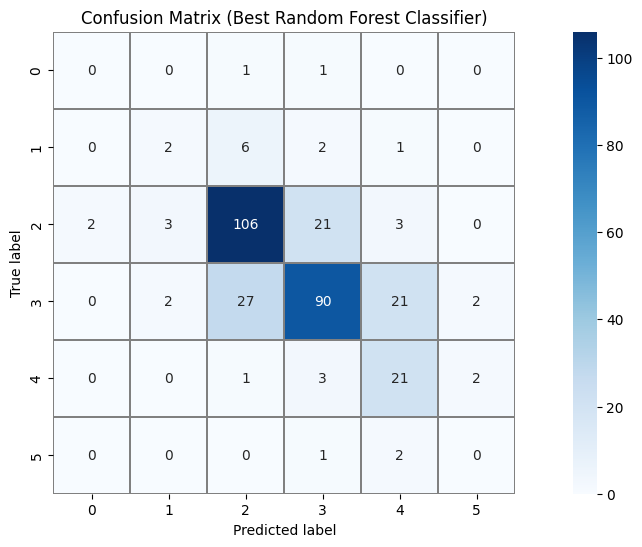


ROC AUC (One-vs-Rest, Best Random Forest): 0.7785
ROC AUC (One-vs-One, Best Random Forest): 0.7638


In [67]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [10, 20, 30, None], # Maximum depth of the tree
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'min_samples_split': [2, 5, 10] # Minimum number of samples required to split an internal node
}

# Initialize a Random Forest Classifier with class_weight='balanced'
# We use the 'balanced' option because we are still dealing with an imbalanced problem,
# even after SMOTE, the original test set reflects the real imbalance.
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# Initialize GridSearchCV
# n_jobs = -1 uses all available CPU cores
# cv = 5 specifies 5-fold cross-validation
# scoring='f1_weighted' is often a good choice for imbalanced multi-class problems,
# as it accounts for class imbalance when averaging F1 scores.
print("Starting GridSearchCV for Random Forest...")
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_weighted')

# Fit GridSearchCV to the SMOTE-resampled training data
# This will perform cross-validation for each parameter combination
grid_search.fit(X_train_resampled, y_train_resampled)

print("GridSearchCV completed.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest Parameters found: {best_params}")
print(f"Best F1 Weighted Score (on training data with CV): {best_score:.4f}")

# Get the best model
best_rf_model = grid_search.best_estimator_

print("\nEvaluating the best Random Forest model on the test set...")
# Make predictions on the original (unresampled) test data with the best model
y_pred_best_rf = best_rf_model.predict(X_test)
y_pred_proba_best_rf = best_rf_model.predict_proba(X_test)

# Evaluation Metrics for the best model
print("\n--- Best Random Forest Classifier Evaluation ---")
print(f"Test Accuracy: {best_rf_model.score(X_test, y_test):.4f}")

print("\n--- Classification Report (Best Random Forest) ---")
print(classification_report(y_test, y_pred_best_rf))

# Confusion Matrix for the best model
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)

f, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(cm_best_rf, annot=True, cmap='Blues', fmt='d', square=True, linewidths=0.01, linecolor='grey')
plt.title('Confusion Matrix (Best Random Forest Classifier)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# ROC AUC Score (One-vs-Rest) for the best model
roc_auc_best_rf_ovr = roc_auc_score(y_test, y_pred_proba_best_rf, multi_class='ovr')
print(f"\nROC AUC (One-vs-Rest, Best Random Forest): {roc_auc_best_rf_ovr:.4f}")

# ROC AUC Score (One-vs-One) for the best model
roc_auc_best_rf_ovo = roc_auc_score(y_test, y_pred_proba_best_rf, multi_class='ovo')
print(f"ROC AUC (One-vs-One, Best Random Forest): {roc_auc_best_rf_ovo:.4f}")

### Analysis of Random Forest Classifier Results

Let's analyze the performance of our Random Forest model and compare it to the Neural Network.

*   **Test Accuracy**: Compare this to the Neural Network's 49.4% accuracy (after SMOTE) and the original 61.6% accuracy.
*   **Classification Report**: Pay close attention to the precision, recall, and f1-score for the minority classes (0, 1, 4, 5). Has the Random Forest improved prediction for these? Often, tree-based models handle imbalance more gracefully or yield better F1-scores for minority classes even if overall accuracy isn't drastically higher.
*   **Confusion Matrix**: Visualize how well the Random Forest distinguishes between classes. Are there fewer misclassifications for the rare classes now?
*   **ROC AUC Score**: A high AUC confirms the model's ability to discriminate between classes effectively. Compare these scores to the neural network's ~0.749.

This comparison will give us valuable insights into which model type (or approach) is more promising for our wine quality prediction task, especially when dealing with the class imbalance. Based on these results, we can then decide on further steps, such as more in-depth hyperparameter tuning for the better-performing model, or exploring ensemble methods.

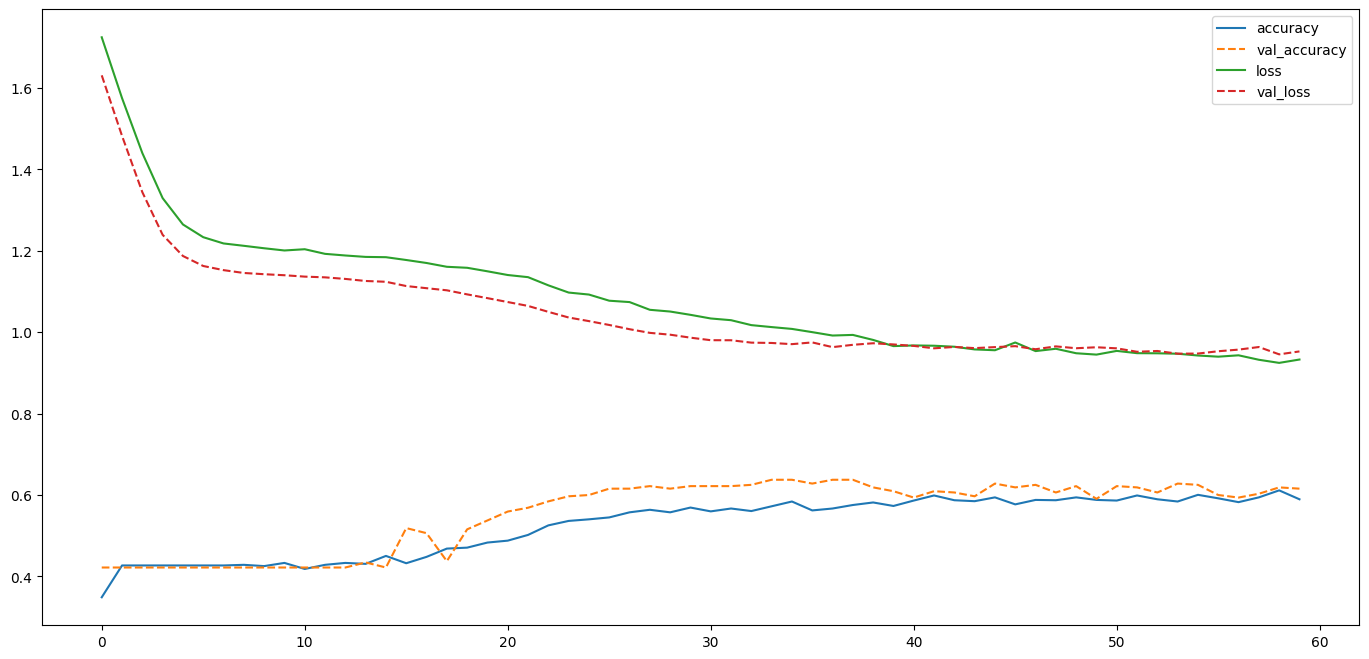

In [52]:
fig, ax = plt.subplots(figsize=(17,8))

plt.plot(cl.history['accuracy'], label='accuracy')
plt.plot(cl.history['val_accuracy'], label='val_accuracy', linestyle='--')
plt.plot(cl.history['loss'], label='loss')
plt.plot(cl.history['val_loss'], label='val_loss', linestyle='--')
plt.legend()

### Visualizing Training History

This cell is dedicated to plotting the training progress, which is an invaluable tool for understanding how our model learned:

*   **`fig, ax = plt.subplots(figsize=(17,8))`**: Creates a Matplotlib figure and a single subplot, making it large enough for good visibility.

*   **`plt.plot(cl.history['accuracy'], label='accuracy')`**: `cl` (the variable storing the output of `model.fit()`) contains a `history` object. This object holds a dictionary of metrics recorded during training. We're plotting the training `accuracy` over the epochs.
*   **`plt.plot(cl.history['val_accuracy'], label='val_accuracy', linestyle='--')`**: Plots the accuracy on the validation set (`val_accuracy`). The `linestyle='--'` makes it a dashed line, which helps distinguish it from the training accuracy.
*   **`plt.plot(cl.history['loss'], label='loss')`**: Plots the training `loss`.
*   **`plt.plot(cl.history['val_loss'], label='val_loss', linestyle='--')`**: Plots the validation `loss`.

*   **`plt.legend()`**: Displays the labels for each line, which we defined with the `label` argument in each `plt.plot()` call.

**How to interpret this plot:**
*   **Training vs. Validation Accuracy**: Ideally, both should increase and converge. If training accuracy keeps going up but validation accuracy plateaus or drops, it indicates **overfitting** (the model is memorizing the training data but not generalizing).
*   **Training vs. Validation Loss**: Ideally, both should decrease. Similar to accuracy, if training loss keeps dropping but validation loss starts rising, it's overfitting.

This plot gives you a quick visual summary of whether your model is learning effectively, if you need more epochs, or if you're overfitting and might need more regularization (like more dropout or a simpler model).

This code visualizes the training history, specifically the `accuracy`, `val_accuracy`, `loss`, and `val_loss` over the epochs. This plot is useful for understanding if the model is learning effectively, if it's overfitting (validation loss increases while training loss decreases), or underfitting (both training and validation loss remain high).

In [53]:
ModelLoss, ModelAccuracy = model.evaluate(X_test, y_test)

print(f'Test Loss is {ModelLoss}')
print(f'Test Accuracy is {ModelAccuracy}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6156 - loss: 0.9529 
Test Loss is 0.9528636932373047
Test Accuracy is 0.6156250238418579


### Evaluating Model Performance on Test Set

After training, this is how we get a final, objective measure of our model's performance on data it has never seen:

*   **`ModelLoss, ModelAccuracy = model.evaluate(X_test, y_test)`**: The `model.evaluate()` method computes the loss and metrics (like accuracy) for the given data.
    *   `X_test`, `y_test`: Crucially, we use our held-out test set here. This data was not used during training or validation, so it provides a true measure of the model's generalization capability.
    *   It returns the final loss and accuracy on this test set.

*   **`print(f'Test Loss is {ModelLoss}')` and `print(f'Test Accuracy is {ModelAccuracy}')`**: These lines simply print the calculated test loss and test accuracy. These are key numbers to report when assessing your model's real-world performance. In our case, an accuracy of 60% on the test set suggests that for 60% of the wines it hadn't seen before, the model correctly predicted their quality rating.

After training, this cell evaluates the model's performance on the unseen test set using `model.evaluate()`. It returns the final `loss` and `accuracy` on the test data, giving a good indication of how well the model generalizes.

In [54]:
y_pred = model.predict(X_test)
y_test_list=list(y_test)
total=len(y_test_list)
correct=0

# for i in range(10):
#   print(f'{i+1} - {y_pred[4][i]:.3f} - {y_test_list[4]}')

for i in range(total):
  # print(f'{np.argmax(y_pred[i])} - {np.amax(y_pred[i])} - {y_test_list[i]}')
  if(np.argmax(y_pred[i])==y_test_list[i]):
    correct+=1

print(f'{correct}/{total}')
print(correct/total)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
197/320
0.615625


### Manual Accuracy Calculation

This cell provides a manual way to calculate the accuracy, reinforcing how the `accuracy` metric is derived:

*   **`y_pred = model.predict(X_test)`**: This uses our trained `model` to make predictions on the `X_test` features. Since our output layer uses `softmax`, `y_pred` will be an array of probability distributions for each sample in `X_test`, where each row corresponds to a wine and each column represents the probability of that wine belonging to a specific quality class (0-5).

*   **`y_test_list=list(y_test)`**: Converts our `y_test` (true labels) into a Python list for easier iteration.

*   **`total=len(y_test_list)`**: Gets the total number of samples in our test set.
*   **`correct=0`**: Initializes a counter for correct predictions.

*   **`for i in range(total): ...`**: We iterate through each prediction and true label:
    *   **`np.argmax(y_pred[i])`**: For each wine's probability distribution (`y_pred[i]`), `np.argmax()` finds the index of the highest probability. This index corresponds to the class our model predicts for that wine. For example, if `y_pred[i]` is `[0.1, 0.05, 0.8, 0.03, 0.01, 0.01]`, `np.argmax()` would return `2`, meaning the model predicts class 2 (original quality 5).
    *   **`if(np.argmax(y_pred[i])==y_test_list[i]): correct+=1`**: This compares our model's predicted class with the actual true class (`y_test_list[i]`). If they match, we increment our `correct` counter.

*   **`print(f'{correct}/{total}')`**: Shows the count of correct predictions out of the total test samples.
*   **`print(correct/total)`**: Prints the calculated accuracy, which should match the `ModelAccuracy` obtained from `model.evaluate()` (or be very close, due to floating point precision). This manual calculation helps demystify the `accuracy` metric.

This cell manually calculates the accuracy of the model on the test set. It predicts the class probabilities for `X_test` using `model.predict()`, then determines the predicted class by finding the index of the maximum probability (`np.argmax`). It then compares these predictions to the actual `y_test` labels to count correct predictions and calculates the overall accuracy.

In [55]:
from sklearn.metrics import confusion_matrix, classification_report

predict=model.predict(X_test)

y_pred=[]
for i in range(len(predict)):
    y_pred.append(np.argmax(predict[i]))

cr = classification_report(y_test, y_pred)
print(cr)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00        11
           2       0.68      0.76      0.72       135
           3       0.64      0.56      0.60       142
           4       0.33      0.52      0.40        27
           5       0.00      0.00      0.00         3

    accuracy                           0.62       320
   macro avg       0.27      0.31      0.29       320
weighted avg       0.60      0.62      0.60       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Detailed Classification Report

While overall accuracy is good, it doesn't tell the whole story, especially with imbalanced datasets. This cell provides a more detailed breakdown of performance:

*   **`from sklearn.metrics import confusion_matrix, classification_report`**: We import these two powerful functions from scikit-learn.

*   **`predict=model.predict(X_test)`**: Again, we get the probability predictions for our test set.

*   **`y_pred=[]` and the loop**: We convert the probability distributions (`predict`) into hard class labels (`y_pred`) by taking `np.argmax()` for each prediction. This is the list of our model's final class predictions.

*   **`cr = classification_report(y_test, y_pred)`**: This function generates a text report showing the main classification metrics for each class:
    *   **Precision**: Out of all samples predicted as a specific class, how many actually belonged to that class? (True Positives / (True Positives + False Positives))
    *   **Recall**: Out of all samples that *actually belonged* to a specific class, how many did the model correctly identify? (True Positives / (True Positives + False Negatives))
    *   **F1-score**: The harmonic mean of precision and recall. It's a good single metric that balances both.
    *   **Support**: The number of actual occurrences of the class in the specified dataset (`y_test`). This is where we see the class imbalance again.
    *   **Accuracy**: The overall accuracy (same as before).
    *   **Macro Avg**: The average of metrics (precision, recall, f1-score) calculated independently for each class. It treats all classes equally.
    *   **Weighted Avg**: The average of metrics weighted by the number of true instances for each class. This gives a better sense of overall performance when classes are imbalanced.

**Warning about `UndefinedMetricWarning`**: You might see warnings about 'Precision and F-score are ill-defined'. This happens when a class has no predicted samples (the model never predicted that class) or no true samples. For example, if our model never predicted a 'quality 0' wine, its precision for 'quality 0' would be undefined. This is common with highly imbalanced datasets where a model might struggle to predict minority classes.

This cell generates and prints a `classification_report` using `sklearn.metrics`. The classification report provides a detailed breakdown of precision, recall, and f1-score for each class, as well as overall accuracy. This is particularly useful for understanding the model's performance on imbalanced datasets, as it highlights how well each individual class is predicted.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


Text(0.5, 36.72222222222221, 'Predicted label')

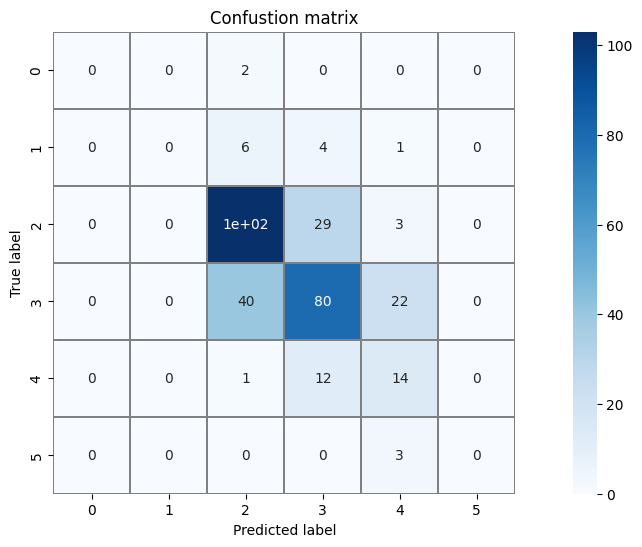

In [56]:
p_test = model.predict(X_test).argmax(axis=1)
cm = tf.math.confusion_matrix(y_test, p_test)

f, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(cm, annot=True, cmap='Blues', square=True, linewidths=0.01, linecolor='grey')
plt.title('Confustion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')

### Visualizing the Confusion Matrix

The confusion matrix is a powerful visualization that gives you an even more granular look at where your model is making mistakes:

*   **`p_test = model.predict(X_test).argmax(axis=1)`**: Similar to before, this gets the predicted class labels (0-5) for each sample in the test set.

*   **`cm = tf.math.confusion_matrix(y_test, p_test)`**: This TensorFlow function computes the confusion matrix.
    *   The rows represent the *actual* (true) classes.
    *   The columns represent the *predicted* classes.
    *   Each cell `[i, j]` shows the number of samples that actually belonged to class `i` but were predicted as class `j`.

*   **`f, ax = plt.subplots(figsize=(15, 6))`**: Sets up our plot figure and axes for good sizing.

*   **`sns.heatmap(cm, annot=True, cmap='Blues', square=True, linewidths=0.01, linecolor='grey')`**: We use seaborn to visualize the matrix:
    *   `cm`: Our confusion matrix.
    *   `annot=True`: Displays the numerical count in each cell, which is very helpful.
    *   `cmap='Blues'`: Uses a blue color scheme, where darker blues indicate higher counts.
    *   `square=True`: Makes the cells square.
    *   `linewidths=0.01`, `linecolor='grey'`: Adds thin grey lines between cells for better visual separation.

*   **`plt.title(...)`, `plt.ylabel(...)`, `plt.xlabel(...)`**: Adds clear labels to our plot.

**How to interpret the Confusion Matrix:**
*   **Diagonal values**: These are the correct predictions (True Positives). For example, `[2, 2]` would be wines that were actually quality 2 and predicted as quality 2. We want these numbers to be as high as possible.
*   **Off-diagonal values**: These are incorrect predictions (False Positives and False Negatives). For example, `[2, 3]` means wines that were *actually* quality 2 were *predicted* as quality 3. These tell us which classes the model is confusing with each other.

This matrix helps us understand if the model is misclassifying certain qualities more than others or if it's consistently confusing, say, quality 5 with quality 6.

This cell computes and visualizes the confusion matrix. The confusion matrix shows the number of correct and incorrect predictions made by the classification model compared to the actual outcomes (true labels) on the test data. `tf.math.confusion_matrix` generates the matrix, and `seaborn.heatmap` visualizes it, with `annot=True` displaying the counts in each cell. This helps to identify which classes are being confused with others.

In [66]:
from sklearn.metrics import roc_auc_score

print(f"One-vs-rest: {roc_auc_score(y_test, model.predict(X_test), multi_class='ovr')}")
print(f"One-vs-one: {roc_auc_score(y_test, model.predict(X_test), multi_class='ovo')}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
One-vs-rest: 0.6625826952848097
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
One-vs-one: 0.6457531115947043


### ROC AUC Score

Finally, this cell calculates the Receiver Operating Characteristic Area Under the Curve (ROC AUC) score, another key metric for classification models:

*   **`from sklearn.metrics import roc_auc_score, plot_roc_curve`**: Imports the necessary function.

*   **`model.predict(X_test)`**: We get the probability predictions for our test set, as ROC AUC works best with probabilities rather than hard class labels.

*   **`roc_auc_score(y_test, model.predict(X_test), multi_class='ovr')`**: Calculates the ROC AUC score for multi-class classification using the 'one-vs-rest' strategy.
    *   **One-vs-Rest (OvR)**: For each class, it treats that class as the positive class and all other classes as the negative class. It then calculates a binary ROC AUC for each such comparison and averages them. This is common when you have more than two classes.

*   **`roc_auc_score(y_test, model.predict(X_test), multi_class='ovo')`**: Calculates the ROC AUC score using the 'one-vs-one' strategy.
    *   **One-vs-One (OvO)**: It computes the average ROC AUC for all possible pairwise combinations of classes. This is another way to extend AUC to multi-class problems.

**What does ROC AUC mean?**
*   The ROC curve plots the True Positive Rate (Sensitivity) against the False Positive Rate (1 - Specificity) at various threshold settings.
*   The **AUC (Area Under the Curve)** represents the degree or measure of separability. It tells us how much the model is capable of distinguishing between classes.
*   A higher AUC (closer to 1.0) means the model is better at separating positive and negative classes (or distinguishing between classes in a multi-class setting). An AUC of 0.5 suggests the model performs no better than random chance.

Our scores (around 0.67 for OvR and 0.65 for OvO) indicate that the model has some ability to distinguish between the different wine quality classes, but there's definitely room for improvement (a perfect classifier would have an AUC of 1.0).

Finally, this cell calculates the ROC AUC (Receiver Operating Characteristic Area Under the Curve) score. ROC AUC is a performance metric for classification problems. For multi-class classification, `multi_class='ovr'` (one-vs-rest) calculates the AUC for each class against all others, and `multi_class='ovo'` (one-vs-one) calculates the average AUC for each pair of classes. A higher ROC AUC score indicates better model performance.